In [1]:
import numpy as np
import matplotlib.pyplot as plt
import os, sys
qapath = os.environ.get("QAssemble")
sys.path.append(qapath+'/src')
# from qacore.FPathDyn import *
from qacore.CorrelationFunction import CorrelationFunction
from qacore.Crystal import Crystal

In [2]:
RVec = [[10,0,0],[0,10,0],[0,0,10]]
Basis = [[[1/2,1/2,1/2],1]]
NSpin = 1
SOC = False
KGrid = [9, 9, 9]
NElec = 1
T = 2000
cutoff = 100
cry = {
    'RVec' : RVec,
   'Basis': Basis,
    'CorF' : 'F',
    'SOC' : SOC,
    'NSpin' : NSpin,
    'NElec' : NElec,
    'KGrid' : KGrid
}
ft = {
    'T' : T,
    'cutoff' : cutoff
}
cf = CorrelationFunction(cry=cry,ft=ft)


In [3]:
impdict = {
    '1'  : [[[0, 0]]]
}
cf.crystal.Projector(impdict=impdict)

In [4]:
t = 1.0
hopping = {
    ((0,0),(0,0)) : {
        t : [[0,0,1],[1,0,0],[0,1,0]]
    }
}
cf.TightBinding(hopping=hopping,fn=None)

In [5]:
from qacore.FPathStc import FPathStc
fpathstc = FPathStc(crystal=cf.crystal,obj=cf.niham)

***** DOS Calculation Start *****
***** Fourier transfrom R2K Start *****
***** Fourier transfrom R2K Finish *****
***** Hamiltonian Diagonalization Start *****
***** Hamiltonian Diagonalization Finish *****
***** Gaussian Approach Start *****
***** Gaussian Approach Finish *****
Integration gaussian : 1.0
Integration dos : (0.9999999999999993+0j)


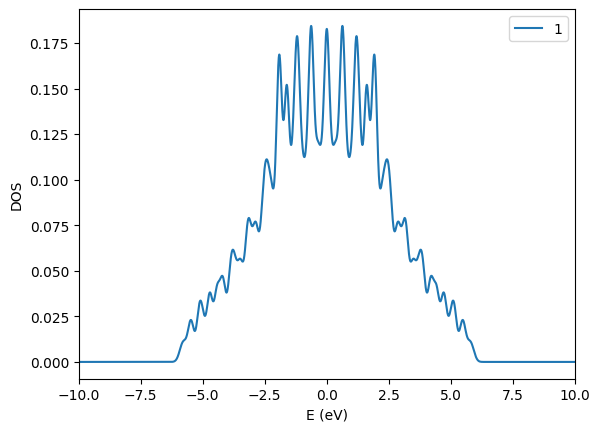

In [6]:
fpathstc.Dos(matr=cf.niham.r,plotoption=True)

In [7]:
kpath = [[0,0,0],[1/2,0,0],[1/2,1/2,0],[0,0,0]]
nkpath = 101
fpathstc.crystal.Kpath(kpath, nkpath)

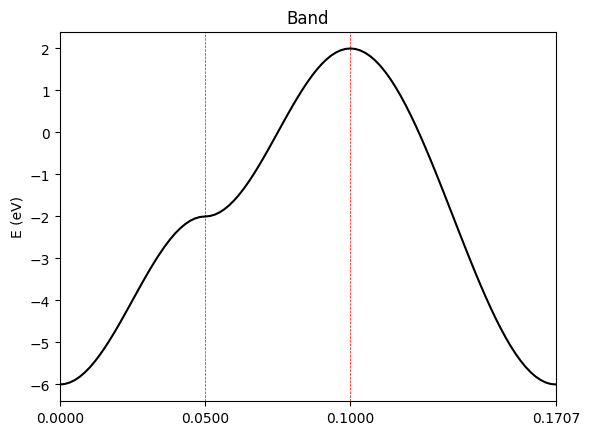

In [8]:
fpathstc.Band(hmat = cf.niham.r, plotoption=True)

# GW Approximation

In [9]:
U = 5
Up = 0
J = 0
V = 1.0

locoption = {
    "Parameter" : "SlaterKanamori",
    "option" : {
        1 : {
            'l' : 0,
            'value' : [U,Up,J],
            'orbitals' : [0]
        }
    }
}
nonlocoption = {
    ((0,0),(0,0)) : {
        V : [[0,0,1],[1,0,0],[0,1,0]]
    }
}


In [10]:
from qacore.BLatStc import VBare

In [11]:
vbare = VBare(crystal=cf.crystal,orboption=locoption,intamp=nonlocoption,hdf5file='test.h5',group='gw')

1
Only calculate the odd number of orbitals
[[5.]]


In [12]:
itermax = 1
mix = 0.1


cf.GWApproximation(itermax = itermax, mix = mix, hoppinglist=hopping, loccoulomb = locoption, nonloccoulomb=nonlocoption)

[[-6.+0.j]]
1
Only calculate the odd number of orbitals
[[5.]]
[[-6.+0.j]]
Bare Green's function : 
[[0.16532041-0.01491859j]]
Initialization start
Initialization finish
Finding chemical potential start
minimum : -59.450422874624664, maximum : 59.450422874624664
Finding chemical potential finish
Chemical potential shift start
Chemical potential shift finish
Density matrixy calculation start
Density matrixy calculation finish
[[[0.5+2.75401343e-16j]]]
Hartree calculation start
Hartree calculation finish
Fock calculation start
Fock calculation finish
Polarizability calculation start
Polarizability calculation finish
Screened coulomb interaction calculation start
Screened coulomb interaction calculation finish
GW self-energy calculation start
GW self-energy calculation finish
GW green's function calculation start
Bare Green's function : 
[[0.16532041-0.01491859j]]
Initialization start
[[0.+0.j]]
(10.999999994974415+6.0588295551175915e-15j)
[[0.+0.j]]
[[0.+0.j]]
[[-3.4924689-1.43003214e-15

In [13]:
qapath = os.environ.get("QAssemble")
sys.path.append(qapath+'/src/qacore/modules')

import QAFort

In [14]:
print(cf.crystal.fprojector.shape)

(1, 1, 1, 1)


In [15]:
print(cf.crystal.probspace)

{'1': [0]}


In [16]:
norbc = cf.crystal.fprojector.shape[1]
nspace = cf.crystal.fprojector.shape[3]

In [17]:
nomega = len(cf.ft.omega)
gloc = np.zeros((norbc, norbc, cf.crystal.ns, nomega, nspace), dtype=np.complex128, order='F')

for ispace in range(nspace):
    gloc[...,ispace]  = QAFort.projection.flatdyn(cf.green.kf, cf.crystal.fprojector[...,ispace])

In [18]:
from qacore.FLocDyn import FLocDyn

In [19]:
flocdyn = FLocDyn(crystal = cf.crystal, ft = cf.ft)

In [20]:
gimp = flocdyn.Loc2Imp(matloc = gloc)